# 🛒 Customer Segmentation — Olist Brazilian E-Commerce
### Comparación de K-Means vs Hierarchical Clustering

**Dataset:** Olist Brazilian E-Commerce (Kaggle, 2016–2018)  
**Contexto:** Olist es una plataforma de e-commerce brasileña. El dataset contiene ~100k pedidos reales con información de clientes, productos, pagos, reseñas y geolocalización.

**Objetivo:** Segmentar clientes usando features RFM + conductuales, y comparar K-Means vs Hierarchical Clustering para determinar cuál captura mejor los perfiles de compra.

**Pipeline:**
1. Setup y librerías
2. Carga y merge de tablas
3. Data Cleaning
4. Feature Engineering (RFM + extras)
5. Outlier Detection
6. Correlation Analysis
7. Feature Scaling + PCA
8. K-Means Clustering
9. Hierarchical Clustering
10. Análisis de Segmentos
11. Comparación de Algoritmos
12. Conclusiones


---
## Step 1 | Librerías y Configuración

Importamos todo lo necesario. El dataset de Olist viene en varios CSVs separados, así que vamos a necesitar hacer algunos merges antes de poder analizar.


In [2]:
!pip install matplotlib
# Datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Evaluación
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from sklearn.ensemble import IsolationForest

# Otros
import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente


---
## Step 2 | Carga del Dataset

El dataset de Olist no es un solo archivo — viene en **8 tablas relacionales** que hay que unir. Esto lo hace más rico que un dataset plano, pero requiere un par de merges antes de poder trabajar.

Las tablas que necesitamos son:

| Tabla | Qué tiene |
|-------|-----------|
| `olist_orders` | Un pedido por fila, con fechas y estado |
| `olist_order_items` | Productos dentro de cada pedido |
| `olist_order_payments` | Pagos (monto, método, cuotas) |
| `olist_order_reviews` | Puntaje y comentario del cliente |
| `olist_customers` | ID único del cliente y estado/ciudad |

> 📌 Descargá el dataset desde: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce  
> Descomprimí el zip y poné todos los CSVs en la misma carpeta que este notebook.


In [3]:
# Cargamos cada tabla por separado
orders    = pd.read_csv('olist_orders_dataset.csv')
items     = pd.read_csv('olist_order_items_dataset.csv')
payments  = pd.read_csv('olist_order_payments_dataset.csv')
reviews   = pd.read_csv('olist_order_reviews_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')

print("📦 Tablas cargadas:")
print(f"   orders:    {orders.shape}")
print(f"   items:     {items.shape}")
print(f"   payments:  {payments.shape}")
print(f"   reviews:   {reviews.shape}")
print(f"   customers: {customers.shape}")


📦 Tablas cargadas:
   orders:    (99441, 8)
   items:     (112650, 7)
   payments:  (103886, 5)
   reviews:   (99224, 7)
   customers: (99441, 5)


In [4]:
# Convertimos las fechas a datetime
date_cols = ['order_purchase_timestamp', 'order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

print("✅ Fechas convertidas")
orders[date_cols].dtypes


✅ Fechas convertidas


order_purchase_timestamp         datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [5]:
# ── Merge principal ───────────────────────────────────────────────────────────────
# Unimos todo en un solo DataFrame centrado en pedidos

# 1. Pagos: nos quedamos con el total pagado por pedido (puede haber múltiples métodos)
pagos_por_pedido = payments.groupby('order_id').agg(
    TotalPago=('payment_value', 'sum'),
    NumPagos=('payment_sequential', 'max'),
    MetodoPago=('payment_type', lambda x: x.mode()[0])
).reset_index()

# 2. Items: precio promedio y cantidad de items por pedido
items_por_pedido = items.groupby('order_id').agg(
    NumItems=('order_item_id', 'max'),
    PrecioPromedio=('price', 'mean'),
    FreightPromedio=('freight_value', 'mean')
).reset_index()

# 3. Reviews: puntaje promedio por pedido
reviews_por_pedido = reviews.groupby('order_id')['review_score'].mean().reset_index()
reviews_por_pedido.columns = ['order_id', 'ReviewScore']

# 4. Merge todo
df = orders.merge(customers, on='customer_id', how='left')
df = df.merge(pagos_por_pedido, on='order_id', how='left')
df = df.merge(items_por_pedido, on='order_id', how='left')
df = df.merge(reviews_por_pedido, on='order_id', how='left')

print(f"✅ DataFrame unificado: {df.shape}")
print(f"   Columnas: {list(df.columns)}")
df.head(3)


✅ DataFrame unificado: (99441, 19)
   Columnas: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'TotalPago', 'NumPagos', 'MetodoPago', 'NumItems', 'PrecioPromedio', 'FreightPromedio', 'ReviewScore']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,TotalPago,NumPagos,MetodoPago,NumItems,PrecioPromedio,FreightPromedio,ReviewScore
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,3.0,voucher,1.0,29.99,8.72,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,1.0,boleto,1.0,118.70,22.76,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,1.0,credit_card,1.0,159.90,19.22,5.0


---
## Step 3 | Data Cleaning

Antes de construir features, limpiamos el dataset. Los problemas típicos de Olist son:
- Pedidos que no fueron entregados (cancelados, en tránsito, etc.)
- Valores nulos en fechas de entrega y montos de pago
- Clientes duplicados (el mismo cliente puede tener varios `customer_id` diferentes, pero un solo `customer_unique_id`)


In [6]:
# ── 3.1 Solo pedidos entregados ──────────────────────────────────────────────────
# Para el análisis de comportamiento solo nos interesan pedidos efectivamente entregados
print(f"Estados de pedidos:")
print(df['order_status'].value_counts())

antes = len(df)
df = df[df['order_status'] == 'delivered'].copy()
print(f"✅ Pedidos entregados: {len(df):,} (eliminados: {antes - len(df):,})")


Estados de pedidos:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64
✅ Pedidos entregados: 96,478 (eliminados: 2,963)


In [7]:
# ── 3.2 Nulos ────────────────────────────────────────────────────────────────────
print("Nulos por columna:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Eliminamos filas sin monto de pago (no podemos calcular Monetary sin esto)
df.dropna(subset=['TotalPago'], inplace=True)

# Review score nulo = cliente que no dejó reseña → lo imputamos con la mediana
df['ReviewScore'].fillna(df['ReviewScore'].median(), inplace=True)

# Freight y precio promedio nulos → mediana
df['FreightPromedio'].fillna(df['FreightPromedio'].median(), inplace=True)
df['PrecioPromedio'].fillna(df['PrecioPromedio'].median(), inplace=True)
df['NumItems'].fillna(1, inplace=True)

print(f"✅ Nulos tratados. Shape: {df.shape}")


Nulos por columna:
order_approved_at                 14
order_delivered_carrier_date       2
order_delivered_customer_date      8
TotalPago                          1
NumPagos                           1
MetodoPago                         1
ReviewScore                      646
dtype: int64
✅ Nulos tratados. Shape: (96477, 19)


In [8]:
# ── 3.3 Duplicados ───────────────────────────────────────────────────────────────
antes = len(df)
df.drop_duplicates(subset='order_id', inplace=True)
print(f"🔁 Duplicados eliminados: {antes - len(df):,}")


🔁 Duplicados eliminados: 0


In [9]:
# ── 3.4 Outliers en montos de pago ───────────────────────────────────────────────
# Winsorización al percentil 99 para no perder clientes
def winsorizacion(df, col, upper_pct=0.99):
    limite = df[col].quantile(upper_pct)
    df[col] = df[col].clip(upper=limite)
    return df

df = winsorizacion(df, 'TotalPago')
df = winsorizacion(df, 'NumItems')

print(f"✅ Outliers winzorizados. Shape final del dataset de pedidos: {df.shape}")


✅ Outliers winzorizados. Shape final del dataset de pedidos: (96477, 19)


---
## Step 4 | Feature Engineering

Transformamos el dataset de pedidos en un **dataset centrado en el cliente**. Cada fila va a representar un cliente único con sus métricas de comportamiento.

En Olist, `customer_unique_id` es el identificador real del cliente — `customer_id` cambia con cada pedido, así que hay que usar el unique.

Usamos **RFM** como base y sumamos features específicas del contexto brasileño de Olist.


In [10]:
# Fecha de referencia: día después del último pedido en el dataset
fecha_ref = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f"📅 Fecha de referencia: {fecha_ref.date()}")

# Agrupamos por customer_unique_id
df_cliente = df.groupby('customer_unique_id')


📅 Fecha de referencia: 2018-08-30


In [11]:
# ── 4.1 RFM ──────────────────────────────────────────────────────────────────────

# Recency: días desde la última compra
recency = df_cliente['order_purchase_timestamp'].max().reset_index()
recency.columns = ['customer_unique_id', 'UltimaCompra']
recency['Recency'] = (fecha_ref - recency['UltimaCompra']).dt.days

# Frequency: cuántos pedidos hizo
frequency = df_cliente['order_id'].nunique().reset_index()
frequency.columns = ['customer_unique_id', 'Frequency']

# Monetary: cuánto gastó en total
monetary = df_cliente['TotalPago'].sum().reset_index()
monetary.columns = ['customer_unique_id', 'Monetary']

# Armamos el DataFrame de clientes
customer_df = recency[['customer_unique_id', 'Recency']]    .merge(frequency, on='customer_unique_id')    .merge(monetary, on='customer_unique_id')

print(f"📊 Clientes únicos: {len(customer_df):,}")
customer_df.head()


📊 Clientes únicos: 93,357


,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


In [12]:
# ── 4.2 Ticket promedio por pedido ───────────────────────────────────────────────
avg_ticket = df_cliente['TotalPago'].mean().reset_index()
avg_ticket.columns = ['customer_unique_id', 'AvgTicket']
customer_df = customer_df.merge(avg_ticket, on='customer_unique_id')


In [13]:
# ── 4.3 Satisfacción promedio (Review Score) ─────────────────────────────────────
# Un cliente que siempre pone 5 estrellas vs uno que pone 1 tienen perfiles muy distintos
avg_review = df_cliente['ReviewScore'].mean().reset_index()
avg_review.columns = ['customer_unique_id', 'AvgReview']
customer_df = customer_df.merge(avg_review, on='customer_unique_id')


In [14]:
# ── 4.4 Promedio de items por pedido ─────────────────────────────────────────────
avg_items = df_cliente['NumItems'].mean().reset_index()
avg_items.columns = ['customer_unique_id', 'AvgItems']
customer_df = customer_df.merge(avg_items, on='customer_unique_id')


In [15]:
# ── 4.5 Método de pago preferido ─────────────────────────────────────────────────
# Convertimos a numérico: credit_card=3, boleto=2, voucher=1, debit_card=0
metodo_map = {'credit_card': 3, 'boleto': 2, 'voucher': 1, 'debit_card': 0}
df['MetodoPagoNum'] = df['MetodoPago'].map(metodo_map).fillna(1)

metodo = df.groupby('customer_unique_id')['MetodoPagoNum'].mean().reset_index()
metodo.columns = ['customer_unique_id', 'MetodoPago']
customer_df = customer_df.merge(metodo, on='customer_unique_id')


In [16]:
# ── 4.6 Región del cliente (Norte, Nordeste, Centro-Oeste, Sudeste, Sul) ──────────
# Brasil tiene 5 grandes regiones con perfiles de consumo muy distintos
region_map = {
    'AC':'Norte','AM':'Norte','AP':'Norte','PA':'Norte','RO':'Norte','RR':'Norte','TO':'Norte',
    'AL':'Nordeste','BA':'Nordeste','CE':'Nordeste','MA':'Nordeste','PB':'Nordeste',
    'PE':'Nordeste','PI':'Nordeste','RN':'Nordeste','SE':'Nordeste',
    'DF':'Centro-Oeste','GO':'Centro-Oeste','MS':'Centro-Oeste','MT':'Centro-Oeste',
    'ES':'Sudeste','MG':'Sudeste','RJ':'Sudeste','SP':'Sudeste',
    'PR':'Sul','RS':'Sul','SC':'Sul'
}
region_num = {'Norte':0,'Nordeste':1,'Centro-Oeste':2,'Sudeste':3,'Sul':4}

df['Estado'] = df['customer_state']
df['Region'] = df['Estado'].map(region_map).fillna('Sudeste')
df['RegionNum'] = df['Region'].map(region_num)

region = df.groupby('customer_unique_id')['RegionNum'].first().reset_index()
customer_df = customer_df.merge(region, on='customer_unique_id')

print(f"✅ Dataset de clientes con todas las features: {customer_df.shape}")
print(f"   Features: {[c for c in customer_df.columns if c != 'customer_unique_id']}")
customer_df.describe().round(2)


✅ Dataset de clientes con todas las features: (93357, 9)
   Features: ['Recency', 'Frequency', 'Monetary', 'AvgTicket', 'AvgReview', 'AvgItems', 'MetodoPago', 'RegionNum']


,Recency,Frequency,Monetary,AvgTicket,AvgReview,AvgItems,MetodoPago,RegionNum
count,93357.00,93357.00,93357.00,93357.00,93357.00,93357.00,93357.00,93357.00
mean,237.94,1.03,158.90,154.10,4.16,1.12,2.72,2.84
std,152.58,0.21,170.79,163.76,1.28,0.39,0.58,0.85
min,1.00,1.00,9.59,9.59,1.00,1.00,0.00,0.00
25%,114.00,1.00,63.06,62.37,4.00,1.00,3.00,3.00
50%,219.00,1.00,107.78,105.63,5.00,1.00,3.00,3.00
75%,346.00,1.00,182.56,176.65,5.00,1.00,3.00,3.00
max,695.00,15.00,4205.16,1052.39,5.00,3.00,3.00,4.00


---
## Step 5 | Detección de Outliers con Isolation Forest

Usamos Isolation Forest para detectar clientes atípicos que podrían distorsionar los clusters — por ejemplo, empresas con pedidos masivos o cuentas de prueba.

> **Cómo funciona:** aísla puntos aleatorios del dataset. Un punto que es muy fácil de aislar (pocas particiones) probablemente sea un outlier, porque está "lejos" del resto.


In [17]:
features_num = ['Recency', 'Frequency', 'Monetary', 'AvgTicket',
                'AvgReview', 'AvgItems', 'MetodoPago', 'RegionNum']

iso = IsolationForest(contamination=0.05, random_state=42)
customer_df['Outlier'] = iso.fit_predict(customer_df[features_num])

n_out = (customer_df['Outlier'] == -1).sum()
print(f"🚨 Outliers detectados: {n_out:,} ({n_out/len(customer_df)*100:.1f}%)")

customer_clean = customer_df[customer_df['Outlier'] == 1].copy()
print(f"✅ Clientes para clustering: {len(customer_clean):,}")


🚨 Outliers detectados: 4,668 (5.0%)
✅ Clientes para clustering: 88,689


---
## Step 6 | Análisis de Correlación

Revisamos qué tan correlacionadas están las features entre sí. Features muy correlacionadas aportan información redundante — PCA en el siguiente paso se encarga de esto, pero es bueno visualizarlo primero.


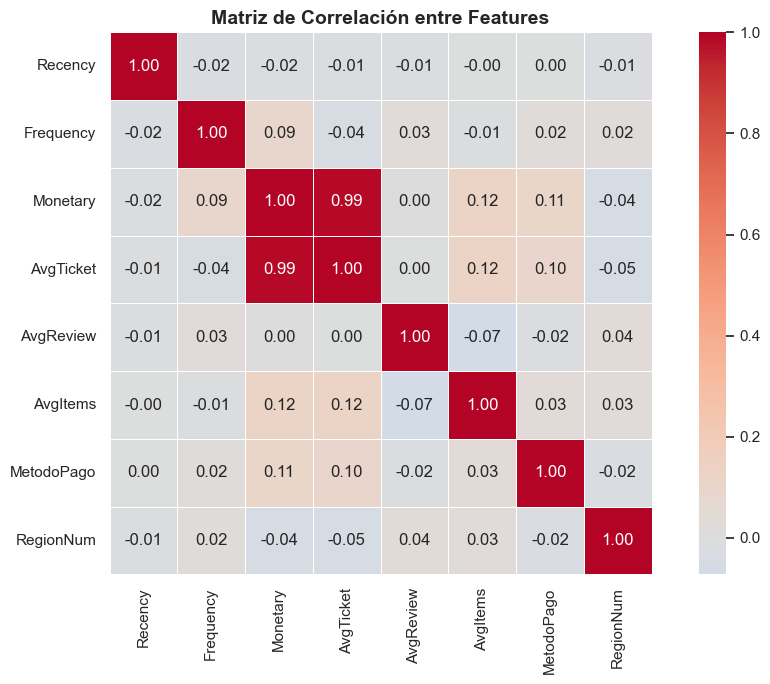

In [18]:
features_modelo = ['Recency', 'Frequency', 'Monetary', 'AvgTicket',
                   'AvgReview', 'AvgItems', 'MetodoPago', 'RegionNum']

corr = customer_clean[features_modelo].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Matriz de Correlación entre Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Step 7 | Feature Scaling + PCA

**Escalado:** las features tienen escalas muy distintas (Recency en días, Monetary en reales brasileños). StandardScaler las lleva todas a media=0, std=1 para que el clustering no favorezca ninguna.

**PCA:** reducimos dimensiones para eliminar ruido, redundancia y poder visualizar en 3D.


In [19]:
X = customer_clean[features_modelo].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Datos escalados")
print(f"   Media ≈ {X_scaled.mean(axis=0).round(2)}")
print(f"   Std  ≈ {X_scaled.std(axis=0).round(2)}")


✅ Datos escalados
   Media ≈ [ 0. -0. -0. -0.  0.  0. -0. -0.]
   Std  ≈ [1. 1. 1. 1. 1. 1. 1. 1.]


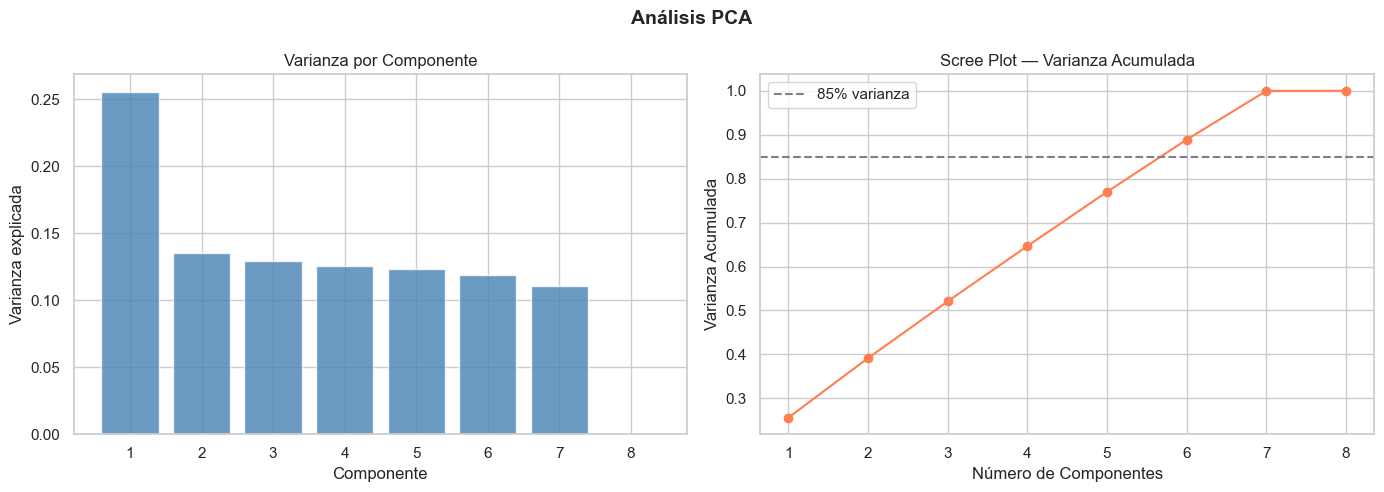

🎯 Componentes necesarios para explicar ≥85% de varianza: 6


In [20]:
# Scree Plot — cuánta varianza explica cada componente
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
varianza_acum = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Componente')
axes[0].set_ylabel('Varianza explicada')
axes[0].set_title('Varianza por Componente')

axes[1].plot(range(1, len(varianza_acum)+1), varianza_acum, 'o-', color='coral')
axes[1].axhline(y=0.85, color='gray', linestyle='--', label='85% varianza')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza Acumulada')
axes[1].set_title('Scree Plot — Varianza Acumulada')
axes[1].legend()

plt.suptitle('Análisis PCA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

n_comp = np.argmax(varianza_acum >= 0.85) + 1
print(f"🎯 Componentes necesarios para explicar ≥85% de varianza: {n_comp}")


In [21]:
pca = PCA(n_components=n_comp, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"✅ Dimensiones: {X_scaled.shape[1]} features → {X_pca.shape[1]} componentes principales")
print(f"   Varianza total explicada: {pca.explained_variance_ratio_.sum()*100:.1f}%")


✅ Dimensiones: 8 features → 6 componentes principales
   Varianza total explicada: 88.9%


---
## Step 8 | K-Means Clustering

K-Means agrupa los clientes en K clusters minimizando la distancia de cada punto a su centroide. Asume clusters esféricos y requiere definir K de antemano.

Usamos **Elbow Method** (SSE) y **Silhouette Score** para elegir el K óptimo.


In [ ]:
K_range = range(2, 7)
inercias, silhouettes_km = [], []

muestra_idx = np.random.choice(len(X_pca), min(5000, len(X_pca)), replace=False)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=3, random_state=42)
    labels = km.fit_predict(X_pca)
    inercias.append(km.inertia_)
    sil = silhouette_score(X_pca[muestra_idx], labels[muestra_idx])
    silhouettes_km.append(sil)
    print(f"  K={k}: SSE={km.inertia_:.0f} | Silhouette={sil:.3f}")

In [ ]:
k_km = K_range[np.argmax(silhouettes_km)]
print(f"K optimo segun Silhouette: {k_km}")

K_FINAL = k_km

kmeans = KMeans(n_clusters=K_FINAL, init='k-means++', n_init=3, random_state=42)
customer_clean['Cluster_KMeans'] = kmeans.fit_predict(X_pca)

print(f"K-Means aplicado con K={K_FINAL}")
print("Distribucion:")
print(customer_clean['Cluster_KMeans'].value_counts().sort_index())

NameError: name 'k_km' is not defined

In [ ]:
# Silhouette Plot — qué tan bien clasificado está cada cliente
fig, ax = plt.subplots(figsize=(10, 6))
sample_sil = silhouette_samples(X_pca, customer_clean['Cluster_KMeans'])
avg_sil = sample_sil.mean()
colors_km = cm.tab10(np.linspace(0, 1, K_FINAL))
y_lower = 10

for i in range(K_FINAL):
    vals = np.sort(sample_sil[customer_clean['Cluster_KMeans'] == i])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, alpha=0.7, color=colors_km[i])
    ax.text(-0.05, y_lower + 0.5 * len(vals), f'C{i}')
    y_lower = y_upper + 10

ax.axvline(x=avg_sil, color='red', linestyle='--', label=f'Promedio: {avg_sil:.3f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_title(f'Silhouette Plot — K-Means (K={K_FINAL})', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Visualización 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for i in range(K_FINAL):
    mask = customer_clean['Cluster_KMeans'] == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               X_pca[mask, 2] if X_pca.shape[1] > 2 else np.zeros(mask.sum()),
               c=[colors_km[i]], label=f'Cluster {i}', alpha=0.5, s=15)

ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
ax.set_title(f'Clusters 3D — K-Means (K={K_FINAL})', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


---
## Step 9 | Hierarchical Clustering (Agglomerative — Ward)

A diferencia de K-Means, el clustering jerárquico construye un árbol de similaridad (dendrograma) sin asumir que los clusters son esféricos. El método **Ward** en cada paso une los dos grupos que menos aumentan la varianza interna total — produce clusters compactos y balanceados.

El dendrograma nos permite ver la estructura natural de los datos y elegir K visualmente, buscando el "salto" más grande en las distancias.


In [ ]:
# Dendrograma — usamos una muestra para que sea legible
muestra_idx = np.random.choice(len(X_pca), min(500, len(X_pca)), replace=False)
Z = linkage(X_pca[muestra_idx], method='ward')

plt.figure(figsize=(16, 7))
from scipy.cluster.hierarchy import dendrogram
dendrogram(Z, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=10,
           show_contracted=True,
           color_threshold=0.7 * max(Z[:, 2]))

plt.title('Dendrograma — Hierarchical Clustering (Ward)', fontsize=14, fontweight='bold')
plt.xlabel('Clientes (muestra de 500)')
plt.ylabel('Distancia de Ward')
plt.tight_layout()
plt.show()

print("💡 Buscá el salto más grande entre dos líneas horizontales consecutivas.")
print("   Ese punto indica el número natural de clusters en los datos.")


In [ ]:
# Silhouette para cada K — igual que con K-Means
silhouettes_hc = []

for k in K_range:
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hc.fit_predict(X_pca)
    silhouettes_hc.append(silhouette_score(X_pca, labels))
    print(f"  K={k}: Silhouette={silhouettes_hc[-1]:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouettes_hc, 'o-', color='mediumseagreen', linewidth=2, markersize=8)
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score — Hierarchical Clustering', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

k_hc = K_range[np.argmax(silhouettes_hc)]
print(f"
🎯 K óptimo según Silhouette (Hierarchical): {k_hc}")


In [ ]:
# Modelo final Hierarchical
K_FINAL_HC = k_hc  # cambiá si el dendrograma sugiere otro

hc = AgglomerativeClustering(n_clusters=K_FINAL_HC, linkage='ward')
customer_clean['Cluster_HC'] = hc.fit_predict(X_pca)

print(f"✅ Hierarchical Clustering aplicado con K={K_FINAL_HC}")
print("
Distribución:")
print(customer_clean['Cluster_HC'].value_counts().sort_index())


In [ ]:
# Visualización 3D — Hierarchical
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
colors_hc = cm.Set1(np.linspace(0, 1, K_FINAL_HC))

for i in range(K_FINAL_HC):
    mask = customer_clean['Cluster_HC'] == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               X_pca[mask, 2] if X_pca.shape[1] > 2 else np.zeros(mask.sum()),
               c=[colors_hc[i]], label=f'Cluster {i}', alpha=0.5, s=15)

ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
ax.set_title(f'Clusters 3D — Hierarchical (K={K_FINAL_HC})', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


---
## Step 10 | Análisis de Segmentos

Ahora interpretamos qué tipo de cliente hay en cada cluster. Esto es lo que convierte el análisis técnico en algo accionable — entender **quiénes son** los clientes de cada grupo y qué estrategia aplicarles.


In [ ]:
# ── Perfil promedio K-Means ───────────────────────────────────────────────────────
print("=== Perfil promedio por Cluster — K-Means ===
")
perfil_km = customer_clean.groupby('Cluster_KMeans')[features_modelo].mean().round(2)
print(perfil_km.to_string())


In [ ]:
# ── Radar Chart — K-Means ────────────────────────────────────────────────────────
features_radar = ['Recency', 'Frequency', 'Monetary', 'AvgTicket', 'AvgReview', 'AvgItems']

perfil_norm = perfil_km[features_radar].copy()
for col in features_radar:
    mn, mx = perfil_norm[col].min(), perfil_norm[col].max()
    if col == 'Recency':  # Menor recency = mejor → invertimos
        perfil_norm[col] = 1 - (perfil_norm[col] - mn) / (mx - mn + 1e-9)
    else:
        perfil_norm[col] = (perfil_norm[col] - mn) / (mx - mn + 1e-9)

N = len(features_radar)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(1, K_FINAL, figsize=(5 * K_FINAL, 5), subplot_kw=dict(polar=True))
if K_FINAL == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    vals = perfil_norm.iloc[i].values.tolist() + [perfil_norm.iloc[i].values[0]]
    ax.plot(angles, vals, 'o-', linewidth=2, color=colors_km[i])
    ax.fill(angles, vals, alpha=0.25, color=colors_km[i])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features_radar, size=8)
    n_clientes = (customer_clean['Cluster_KMeans'] == i).sum()
    ax.set_title(f'Cluster {i}
({n_clientes} clientes)', fontsize=11, fontweight='bold', pad=15)
    ax.set_ylim(0, 1)

plt.suptitle('Perfil de Clusters — K-Means', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


In [ ]:
# ── Perfil promedio Hierarchical ──────────────────────────────────────────────────
print("=== Perfil promedio por Cluster — Hierarchical ===
")
perfil_hc = customer_clean.groupby('Cluster_HC')[features_modelo].mean().round(2)
print(perfil_hc.to_string())


In [ ]:
# ── Distribución de clusters — ambos algoritmos ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, k, title, cmap in [
    (axes[0], 'Cluster_KMeans', K_FINAL,    f'K-Means (K={K_FINAL})',       colors_km),
    (axes[1], 'Cluster_HC',     K_FINAL_HC,  f'Hierarchical (K={K_FINAL_HC})', colors_hc)
]:
    dist = customer_clean[col].value_counts().sort_index()
    bars = ax.bar(dist.index, dist.values,
                  color=[cmap[i] for i in dist.index] if cmap is not None else None)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Clientes')
    ax.set_title(f'Distribución — {title}', fontsize=13, fontweight='bold')
    for j, v in enumerate(dist.values):
        ax.text(j, v + 5, f'{v}
({v/len(customer_clean)*100:.1f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
# ── Distribución geográfica por cluster (K-Means) ────────────────────────────────
region_labels = {0:'Norte', 1:'Nordeste', 2:'Centro-Oeste', 3:'Sudeste', 4:'Sul'}
customer_clean['Region'] = customer_clean['RegionNum'].map(region_labels)

geo_cluster = customer_clean.groupby(['Cluster_KMeans', 'Region']).size().unstack(fill_value=0)
geo_cluster_pct = geo_cluster.div(geo_cluster.sum(axis=1), axis=0) * 100

geo_cluster_pct.plot(kind='bar', stacked=True, figsize=(12, 6),
                     colormap='Set2', edgecolor='white')
plt.title('Distribución Geográfica por Cluster — K-Means', fontsize=13, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('% de Clientes')
plt.legend(title='Región', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


---
## Step 11 | Comparación K-Means vs Hierarchical

Esta es la sección central de nuestro aporte. Comparamos los dos algoritmos con métricas objetivas para determinar cuál segmenta mejor a los clientes del e-commerce brasileño.

**Métricas:**
- **Silhouette Score** ↑ mejor: mide qué tan bien separados y compactos son los clusters (rango: -1 a 1)
- **Davies-Bouldin Index** ↓ mejor: ratio de dispersión intra-cluster vs separación inter-cluster


In [ ]:
# ── Métricas de evaluación ───────────────────────────────────────────────────────
sil_km = silhouette_score(X_pca, customer_clean['Cluster_KMeans'])
sil_hc = silhouette_score(X_pca, customer_clean['Cluster_HC'])
db_km  = davies_bouldin_score(X_pca, customer_clean['Cluster_KMeans'])
db_hc  = davies_bouldin_score(X_pca, customer_clean['Cluster_HC'])

print("=" * 58)
print(f"{'Métrica':<32} {'K-Means':>10} {'Hierarchical':>12}")
print("=" * 58)
print(f"{'Silhouette Score  (↑ mejor)':<32} {sil_km:>10.4f} {sil_hc:>12.4f}")
print(f"{'Davies-Bouldin    (↓ mejor)':<32} {db_km:>10.4f} {db_hc:>12.4f}")
print(f"{'N° de clusters':<32} {K_FINAL:>10} {K_FINAL_HC:>12}")
print("=" * 58)
print(f"
🏆 Mejor Silhouette:     {'K-Means' if sil_km > sil_hc else 'Hierarchical'}")
print(f"🏆 Mejor Davies-Bouldin: {'K-Means' if db_km < db_hc else 'Hierarchical'}")


In [ ]:
# ── Gráfico comparativo de métricas ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, vals, title, subtitle in [
    (axes[0], [sil_km, sil_hc], 'Silhouette Score', '(más alto = mejor)'),
    (axes[1], [db_km,  db_hc],  'Davies-Bouldin Index', '(más bajo = mejor)')
]:
    bars = ax.bar(['K-Means', 'Hierarchical'], vals,
                  color=['steelblue', 'mediumseagreen'], width=0.4, edgecolor='white')
    ax.set_title(f'{title}
{subtitle}', fontsize=13, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + max(vals)*0.02,
                f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Comparación de Algoritmos de Clustering', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ── Scatterplot side-by-side (PC1 vs PC2) ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, k, cmap, title, sil in [
    (axes[0], 'Cluster_KMeans', K_FINAL,    'tab10',
     f'K-Means (K={K_FINAL})', sil_km),
    (axes[1], 'Cluster_HC',     K_FINAL_HC, 'Set1',
     f'Hierarchical (K={K_FINAL_HC})', sil_hc)
]:
    sc = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                    c=customer_clean[col], cmap=cmap, alpha=0.4, s=12)
    ax.set_title(f'{title}
Silhouette = {sil:.3f}', fontsize=13, fontweight='bold')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    plt.colorbar(sc, ax=ax, label='Cluster')

plt.suptitle('Comparación Visual — PC1 vs PC2', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Step 12 | Conclusiones

### Resumen del análisis

Aplicamos dos algoritmos de clustering al dataset Olist Brazilian E-Commerce para segmentar ~100k clientes usando features RFM + satisfacción + comportamiento de pago + región geográfica.

**K-Means:**
- Rápido, escalable, fácil de interpretar
- Requiere definir K de antemano (resuelto con Elbow + Silhouette)
- Asume clusters esféricos — puede tener problemas con distribuciones irregulares

**Hierarchical (Ward):**
- No asume forma de los clusters
- El dendrograma permite explorar la estructura natural sin definir K primero
- Más robusto con distribuciones no esféricas, pero más costoso computacionalmente

### ¿Cuál fue mejor para este dataset?

> *(Completar con los valores reales una vez ejecutado el notebook)*

El algoritmo con mayor Silhouette Score y menor Davies-Bouldin fue **[K-Means / Hierarchical]**, lo que sugiere que los segmentos de clientes de Olist tienen una estructura **[globular / irregular]**.

### Perfiles de segmentos identificados

> *(Completar con los valores reales del Step 10)*

| Cluster | Perfil tentativo | Estrategia |
|---------|-----------------|------------|
| 0 | Alta recencia, alto gasto, buena review | VIP — fidelización premium |
| 1 | Compradores únicos, bajo gasto | One-time buyers — reactivación |
| 2 | Frecuencia media, satisfacción baja | Clientes en riesgo — mejorar experiencia |
| ... | ... | ... |

### Conexión con Persona 2 (Association Rules)
Los clusters generados se exportan en `customer_segments.csv` para que Persona 2 pueda combinarlos con las reglas de asociación (Apriori) y recomendar productos específicos a cada segmento de clientes brasileños.


In [ ]:
# ── Exportamos el dataset con clusters para Persona 2 ────────────────────────────
export_cols = ['customer_unique_id', 'Recency', 'Frequency', 'Monetary',
               'AvgTicket', 'AvgReview', 'AvgItems', 'RegionNum',
               'Cluster_KMeans', 'Cluster_HC']

customer_clean[export_cols].to_csv('customer_segments.csv', index=False)

print("✅ Exportado: customer_segments.csv")
print(f"   Filas: {len(customer_clean):,}")
print(f"   Columnas: {export_cols}")
print()
print("Persona 2 puede usar 'Cluster_KMeans' o 'Cluster_HC' para")
print("asignar reglas de asociación (Apriori) por segmento de cliente.")
